![image.png](https://i.imgur.com/4fN73lZ.png)

## Lab 1: Introduction to Reinforcement Learning.



<p align="center">
  <img src="https://gymnasium.farama.org/main/_images/AE_loop.png"
       alt="Agent–Environment Interaction Loop"
       width="400">
</p>

<p align="center">
  <em>
    The reinforcement learning agent–environment interaction loop.
    Source: Gymnasium Documentation.
  </em>
</p>

#### 1. Environments

A reinforcement learning **environment** is the world or problem in which an agent operates.

The environment defines:

| Characteristic | Meaning |
|---|---|
| **Observation space** | Information the agent can receive |
| **Action space** | Actions the agent is allowed to perform |
| **Reward** | Feedback returned after an action |
| **Termination condition** | When the task is successfully or unsuccessfully completed |
| **Maximum episode length** | The maximum number of interaction steps |


<p align="center">
  <img
    src="https://assets-global.website-files.com/60be34ca4d5bca0fc0c89492/65856d9cc782b23da53fd7a2_Project-Management-Success-Factors--Common-Failures-%26-How-To-Avoid-Them.webp"
    alt="Project Management Success Factors and Common Failures"
    width="750"
  >
</p>



In [2]:
%pip install "gymnasium[classic-control,toy-text]" numpy pandas matplotlib imageio imageio-ffmpeg -q


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("Gymnasium version:", gym.__version__)

Gymnasium version: 1.3.0


In [11]:
gym.pprint_registry()

===== classic_control =====
Acrobot-v1             CartPole-v0            CartPole-v1
MountainCar-v0         MountainCarContinuous-v0 Pendulum-v1
===== phys2d =====
phys2d/CartPole-v0     phys2d/CartPole-v1     phys2d/Pendulum-v0
===== box2d =====
BipedalWalker-v3       BipedalWalkerHardcore-v3 CarRacing-v3
LunarLander-v3         LunarLanderContinuous-v3
===== toy_text =====
Blackjack-v1           CliffWalking-v1        CliffWalkingSlippery-v1
FrozenLake-v1          FrozenLake8x8-v1       Taxi-v4
===== tabular =====
tabular/Blackjack-v0   tabular/CliffWalking-v0
===== None =====
Ant-v2                 Ant-v3                 GymV21Environment-v0
GymV26Environment-v0   HalfCheetah-v2         HalfCheetah-v3
Hopper-v2              Hopper-v3              Humanoid-v2
Humanoid-v3            HumanoidStandup-v2     InvertedDoublePendulum-v2
InvertedPendulum-v2    Pusher-v2              Reacher-v2
Swimmer-v2             Swimmer-v3             Walker2d-v2
Walker2d-v3
===== mujoco =====
Ant-v4    

In [11]:
from gymnasium import spaces


def get_space_info(space):
    """Return the space type and its size."""

    if isinstance(space, spaces.Discrete):
        size = space.n

    elif isinstance(space, spaces.MultiDiscrete):
        size = len(space.nvec)

    else:
        size = int(np.prod(space.shape))

    return type(space).__name__, size


def inspect_environment(env_id, **settings):
    """Return basic information about one environment."""

    env = gym.make(env_id, **settings)

    observation_type, observation_size = get_space_info(
        env.observation_space
    )

    action_type, action_size = get_space_info(
        env.action_space
    )

    information = {
        "Environment": env.spec.id,
        "Observation Type": observation_type,
        "Observation Size": observation_size,
        "Action Type": action_type,
        "Action Size": action_size,
        "Maximum Steps": env.spec.max_episode_steps,
    }

    env.close()

    return information

In [12]:
environments = [
    ("FrozenLake-v1", {"map_name": "4x4", "is_slippery": True}),
    ("Taxi-v4", {}),
    ("CartPole-v1", {}),
    ("MountainCar-v0", {}),
    ("Pendulum-v1", {})
]

environment_df = pd.DataFrame(
    inspect_environment(env_id, **settings)
    for env_id, settings in environments
)

environment_df

,Environment,Observation Type,Observation Size,Action Type,Action Size,Maximum Steps
0,FrozenLake-v1,Discrete,16,Discrete,4,100
1,Taxi-v4,Discrete,500,Discrete,6,200
2,CartPole-v1,Box,4,Discrete,2,500
3,MountainCar-v0,Box,2,Discrete,3,200
4,Pendulum-v1,Box,3,Box,1,200


Initial observation: 0
Observation space: Discrete(16)
Number of actions: 4

Actions:
0 = Left
1 = Down
2 = Right
3 = Up


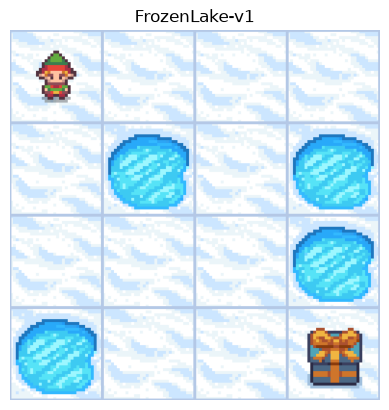

In [13]:
import gymnasium as gym
import matplotlib.pyplot as plt


env = gym.make(
    "FrozenLake-v1",
    render_mode="rgb_array",
    is_slippery=False
)

# Reset environment
observation, info = env.reset()

# Print information
print("Initial observation:", observation)
print("Observation space:", env.observation_space)
print("Number of actions:", env.action_space.n)

print("\nActions:")
print("0 = Left")
print("1 = Down")
print("2 = Right")
print("3 = Up")

# Show the environment
plt.imshow(env.render())
plt.axis("off")
plt.title("FrozenLake-v1")
plt.show()

Initial observation: 386
Observation space: Discrete(500)
Action space: Discrete(6)
Number of actions: 6

Actions:
0 = Move South
1 = Move North
2 = Move East
3 = Move West
4 = Pick up passenger
5 = Drop off passenger


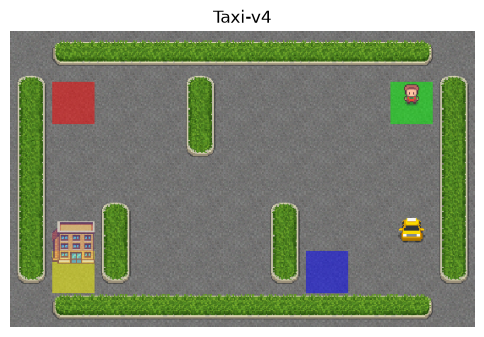

In [14]:
import gymnasium as gym
import matplotlib.pyplot as plt

# Create the Taxi environment
env = gym.make(
    "Taxi-v4",
    render_mode="rgb_array"
)

# Start a new episode
observation, info = env.reset(seed=42)

# Print environment information
print("Initial observation:", observation)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Number of actions:", env.action_space.n)

print("\nActions:")
print("0 = Move South")
print("1 = Move North")
print("2 = Move East")
print("3 = Move West")
print("4 = Pick up passenger")
print("5 = Drop off passenger")

# Display the environment
plt.figure(figsize=(6, 6))
plt.imshow(env.render())
plt.axis("off")
plt.title("Taxi-v4")
plt.show()

Initial observation:
Cart position: -0.03909801
Cart velocity: 0.02593372
Pole angle: 0.02960903
Pole angular velocity: -0.03333576

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)

Actions:
0 = Push cart left
1 = Push cart right


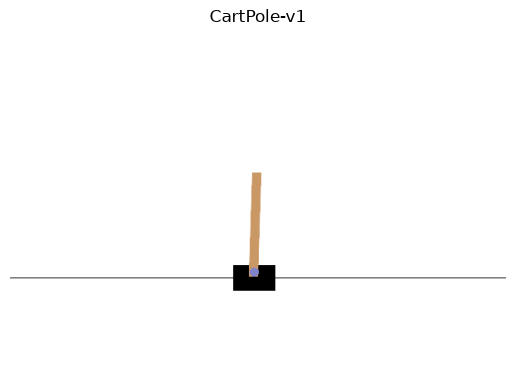

In [15]:
import gymnasium as gym
import matplotlib.pyplot as plt

env = gym.make(
    "CartPole-v1",
    render_mode="rgb_array"
)


observation, info = env.reset()

position, velocity, angle, angular_velocity = observation

print("Initial observation:")
print("Cart position:", position)
print("Cart velocity:", velocity)
print("Pole angle:", angle)
print("Pole angular velocity:", angular_velocity)

print("\nObservation space:", env.observation_space)
print("Action space:", env.action_space)

print("\nActions:")
print("0 = Push cart left")
print("1 = Push cart right")

# Show the environment
plt.imshow(env.render())
plt.axis("off")
plt.title("CartPole-v1")
plt.show()

Initial observation: [-0.56968296  0.        ]
Car position: -0.56968296
Car velocity: 0.0

Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action space: Discrete(3)

Actions:
0 = Push left
1 = No push
2 = Push right


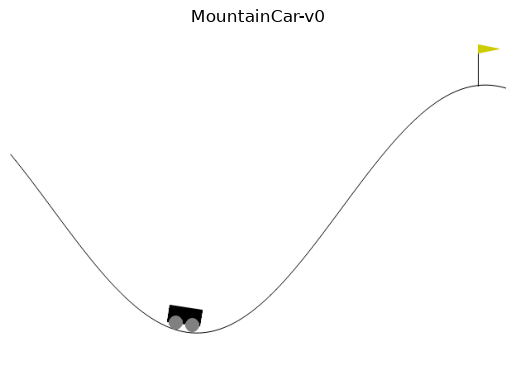

In [16]:
import gymnasium as gym
import matplotlib.pyplot as plt

# Create the environment
env = gym.make(
    "MountainCar-v0",
    render_mode="rgb_array"
)

observation, info = env.reset()

position, velocity = observation

print("Initial observation:", observation)
print("Car position:", position)
print("Car velocity:", velocity)

print("\nObservation space:", env.observation_space)
print("Action space:", env.action_space)

print("\nActions:")
print("0 = Push left")
print("1 = No push")
print("2 = Push right")

# Show the environment
plt.imshow(env.render())
plt.axis("off")
plt.title("MountainCar-v0")
plt.show()

### 2. Agent

An **agent** is the decision-maker in reinforcement learning.

#### 2.1 Agent–Environment Interaction

At every step, the agent and environment exchange information.

| Direction | Information | Symbol | Meaning |
|---|---|---|---|
| Environment → Agent | Observation | $O_t$ | Information describing the current situation |
| Agent → Environment | Action | $A_t$ | Decision selected by the agent |
| Environment → Agent | Reward | $R_{t+1}$ | Feedback produced after the action |
| Environment → Agent | New observation | $O_{t+1}$ | Information after applying the action |
| Environment → Agent | Terminated | — | The task ended because a terminal state was reached |
| Environment → Agent | Truncated | — | The episode stopped because of an external limit, such as the maximum number of steps |
| Environment → Agent | Info | — | Additional diagnostic information |
| Agent ↔ Environment | Episode | — | A complete sequence of interactions from `reset()` until `terminated` or `truncated` becomes `True` |


The interaction follows this sequence:

$$
O_t \rightarrow A_t \rightarrow R_{t+1}, O_{t+1}
$$


Step 1: State 0 → 0, Action = 3, Reward = 0
Step 2: State 0 → 0, Action = 3, Reward = 0
Step 3: State 0 → 0, Action = 0, Reward = 0
Step 4: State 0 → 4, Action = 1, Reward = 0
Step 5: State 4 → 5, Action = 1, Reward = 0


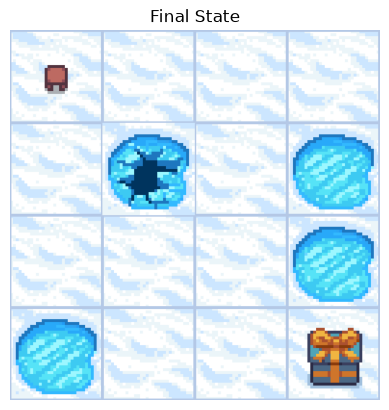


Episode finished
Final reward: 0
Terminated: True
Truncated: False


In [17]:

env = gym.make(
    "FrozenLake-v1",
    render_mode="rgb_array",
    is_slippery=True
)

state, info = env.reset()

# True when the agent reaches the goal or falls into a hole
terminated = False

# True when the maximum number of steps is reached
truncated = False

# Count how many steps the agent takes
step_number = 0
while not terminated and not truncated:

    # Choose a random action
    action = env.action_space.sample()

    # Execute the action
    new_state, reward, terminated, truncated, info = env.step(action)

    step_number += 1

    print(
        f"Step {step_number}: "
        f"State {state} → {new_state}, "
        f"Action = {action}, Reward = {reward}"
    )

    state = new_state

# Show the final environment
plt.imshow(env.render())
plt.axis("off")
plt.title("Final State")
plt.show()

print("\nEpisode finished")
print("Final reward:", reward)
print("Terminated:", terminated)
print("Truncated:", truncated)


#### 3. Rewards and Returns


We will use `Taxi-v4` because it provides different reward values:

| Situation | Reward | Meaning |
|---|---:|---|
| Normal movement | $-1$ | Encourages the taxi to finish quickly |
| Illegal pickup or drop-off | $-10$ | Penalizes an incorrect action |
| Successful delivery | $+20$ | Rewards completion of the task |

A **return** is the total reward collected during an episode:

$$
G = R_1 + R_2 + \cdots + R_T
$$

In [18]:
import imageio
from IPython.display import Image, display


def taxi(env, name, max_steps=50, fps=3):
    frames = []

    state, info = env.reset()
    env.action_space.seed(42)

    total_reward = 0
    frames.append(env.render())

    for step in range(max_steps):

        # Select one random action
        action = env.action_space.sample()

        next_state, reward, terminated, truncated, info = env.step(action)

        total_reward += reward
        frames.append(env.render())

        print(
            f"Step {step + 1}: "
            f"State {state} → {next_state}, "
            f"Action = {action}, "
            f"Reward = {reward}, "
            f"Total Reward = {total_reward}"
        )

        state = next_state

        if terminated or truncated:
            break

    filename = f"{name}.gif"

    imageio.mimsave(
        filename,
        frames,
        fps=fps,
        loop=0
    )

    print("\nEpisode finished")
    print("Number of steps:", step + 1)
    print("Episode return:", total_reward)

    display(Image(filename=filename))

Step 1: State 354 → 454, Action = 0, Reward = -1, Total Reward = -1
Step 2: State 454 → 454, Action = 4, Reward = -10, Total Reward = -11
Step 3: State 454 → 434, Action = 3, Reward = -1, Total Reward = -12
Step 4: State 434 → 454, Action = 2, Reward = -1, Total Reward = -13
Step 5: State 454 → 454, Action = 2, Reward = -1, Total Reward = -14
Step 6: State 454 → 454, Action = 5, Reward = -10, Total Reward = -24
Step 7: State 454 → 454, Action = 0, Reward = -1, Total Reward = -25
Step 8: State 454 → 454, Action = 4, Reward = -10, Total Reward = -35
Step 9: State 454 → 354, Action = 1, Reward = -1, Total Reward = -36
Step 10: State 354 → 454, Action = 0, Reward = -1, Total Reward = -37
Step 11: State 454 → 434, Action = 3, Reward = -1, Total Reward = -38
Step 12: State 434 → 434, Action = 5, Reward = -10, Total Reward = -48
Step 13: State 434 → 434, Action = 4, Reward = -10, Total Reward = -58
Step 14: State 434 → 434, Action = 4, Reward = -10, Total Reward = -68
Step 15: State 434 → 434

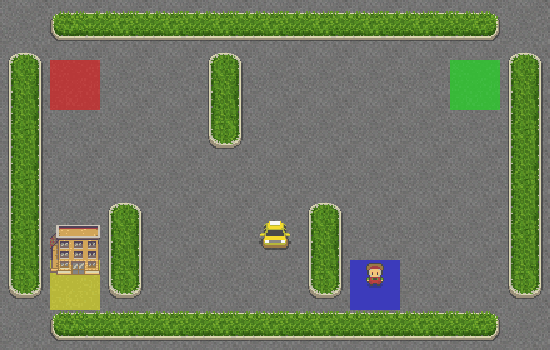

In [19]:
env = gym.make(
    "Taxi-v4",
    render_mode="rgb_array"
)

taxi(
    env,
    "Taxi-v4",
    max_steps=50,
    fps=3
)

env.close()

### 4. Policies 
A **policy** defines how an agent selects an action from an observation.

$$
\pi(O_t) \rightarrow A_t
$$

where:

| Symbol | Meaning |
|---|---|
| $\pi$ | Policy |
| $O_t$ | Observation received by the agent |
| $A_t$ | Action selected by the agent |

A policy may be:

| Policy type | Meaning |
|---|---|
| **Random policy** | Selects an action randomly |
| **Rule-based policy** | Selects an action using predefined rules |
| **Learned policy** | Improves its action selection through training |


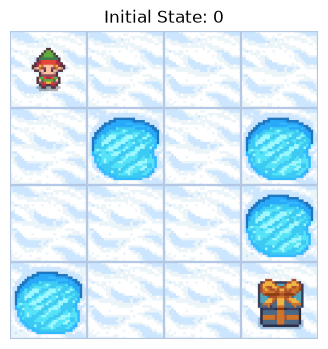

Step 1: State 0 → 1, Action = Right, Reward = 0


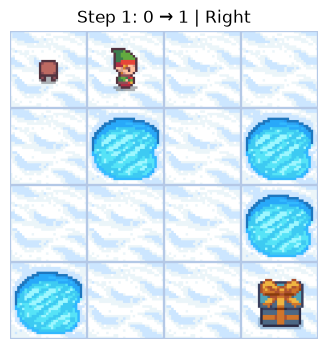

Step 2: State 1 → 2, Action = Right, Reward = 0


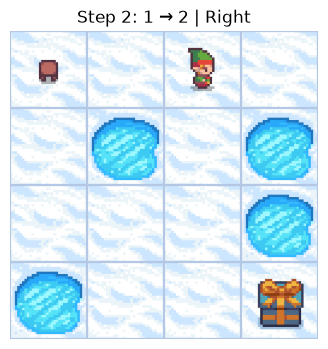

Step 3: State 2 → 6, Action = Down, Reward = 0


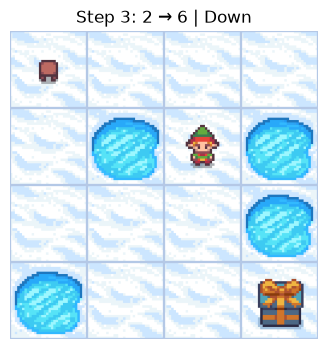

Step 4: State 6 → 10, Action = Down, Reward = 0


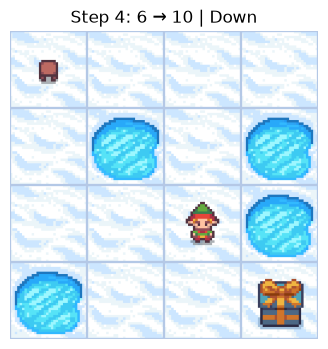

Step 5: State 10 → 14, Action = Down, Reward = 0


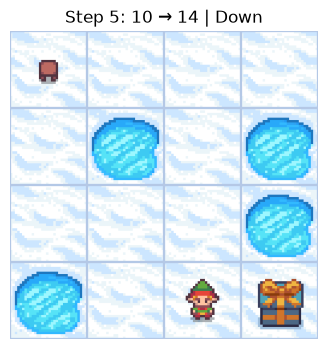

Step 6: State 14 → 15, Action = Right, Reward = 1


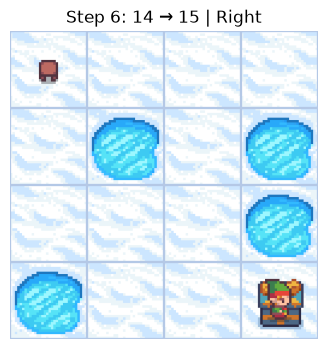

Episode finished.


In [21]:
import gymnasium as gym
import matplotlib.pyplot as plt

env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=False,
    render_mode="rgb_array"
)

# State → Action
winning_policy = {
    0: 2,    # Right
    1: 2,    # Right
    2: 1,    # Down
    6: 1,    # Down
    10: 1,   # Down
    14: 2    # Right to the goal
}

action_names = {
    0: "Left",
    1: "Down",
    2: "Right",
    3: "Up"
}

state, info = env.reset()

# Display the initial state
plt.figure(figsize=(4, 4))
plt.imshow(env.render())
plt.axis("off")
plt.title(f"Initial State: {state}")
plt.show()

for step in range(20):

    action = winning_policy[state]

    next_state, reward, terminated, truncated, info = env.step(action)

    print(
        f"Step {step + 1}: "
        f"State {state} → {next_state}, "
        f"Action = {action_names[action]}, "
        f"Reward = {reward}"
    )

    # Display the image after this action
    plt.figure(figsize=(4, 4))
    plt.imshow(env.render())
    plt.axis("off")
    plt.title(
        f"Step {step + 1}: "
        f"{state} → {next_state} | "
        f"{action_names[action]}"
    )
    plt.show()

    state = next_state

    if terminated or truncated:
        print("Episode finished.")
        break

env.close()

## 5. Markov Decision Process

An MDP is represented as:

$$
M = (S, A, P, R, \gamma)
$$

| Component | Meaning |
|---|---|
| $S$ | Set of all possible states |
| $A$ | Set of all possible actions |
| $P$ | Transition probabilities between states |
| $R$ | Reward returned after an action |
| $\gamma$ | Discount factor that controls the importance of future rewards |

### 5.1 Discount Factor

The **discount factor**, $\gamma$, controls how much future rewards matter.

The discounted return is calculated as:

$$
G_0
=
R_1+\gamma R_2+\gamma^2R_3+\gamma^3R_4+\gamma^4R_5
$$


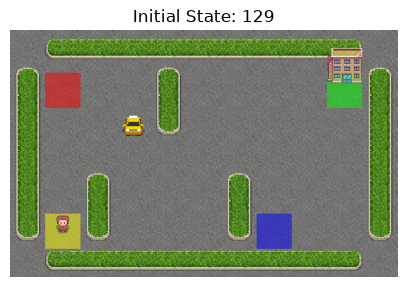

Step 1: State 129 → 229, Action = South, Reward = -1, Discount = 1.0000, Discounted reward = -1.0000


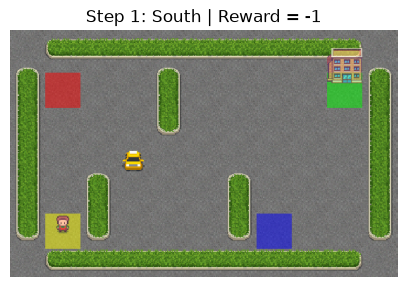

Step 2: State 229 → 329, Action = South, Reward = -1, Discount = 0.9000, Discounted reward = -0.9000


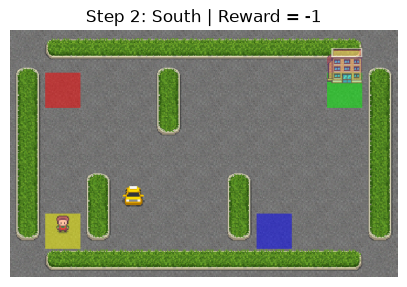

Step 3: State 329 → 329, Action = Pick up, Reward = -10, Discount = 0.8100, Discounted reward = -8.1000


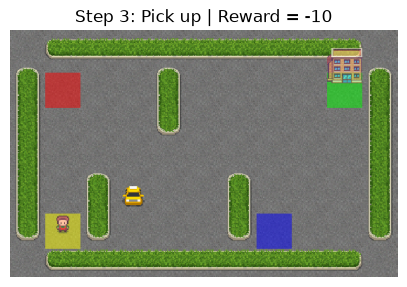

Step 4: State 329 → 229, Action = North, Reward = -1, Discount = 0.7290, Discounted reward = -0.7290


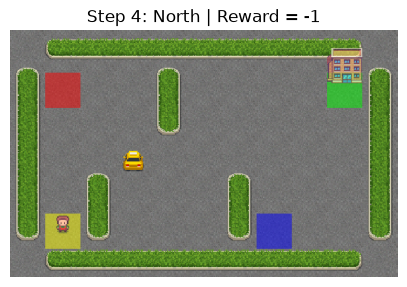

Step 5: State 229 → 229, Action = Pick up, Reward = -10, Discount = 0.6561, Discounted reward = -6.5610


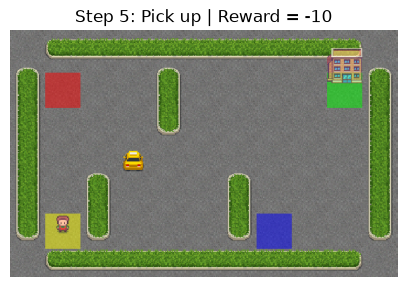

Step 6: State 229 → 229, Action = Drop off, Reward = -10, Discount = 0.5905, Discounted reward = -5.9049


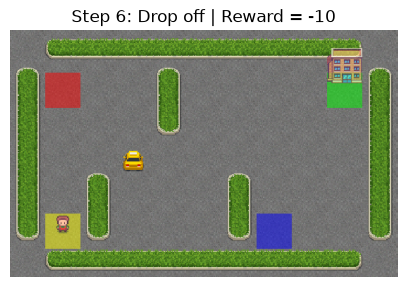

Step 7: State 229 → 229, Action = Pick up, Reward = -10, Discount = 0.5314, Discounted reward = -5.3144


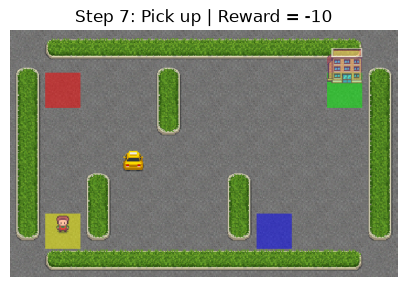

Step 8: State 229 → 229, Action = Drop off, Reward = -10, Discount = 0.4783, Discounted reward = -4.7830


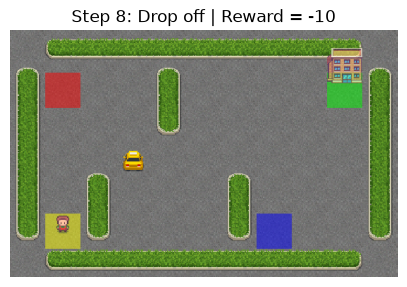

Step 9: State 229 → 329, Action = South, Reward = -1, Discount = 0.4305, Discounted reward = -0.4305


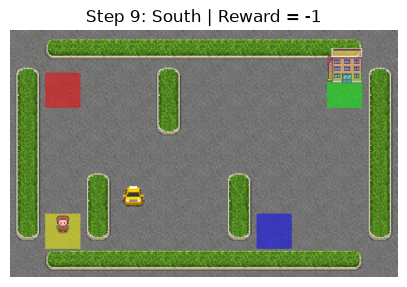

Step 10: State 329 → 329, Action = Pick up, Reward = -10, Discount = 0.3874, Discounted reward = -3.8742


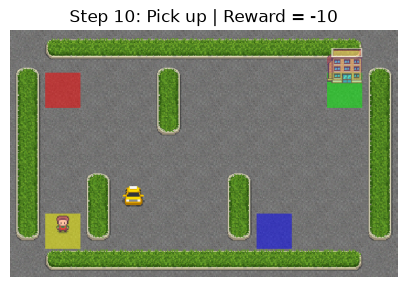

Step 11: State 329 → 349, Action = East, Reward = -1, Discount = 0.3487, Discounted reward = -0.3487


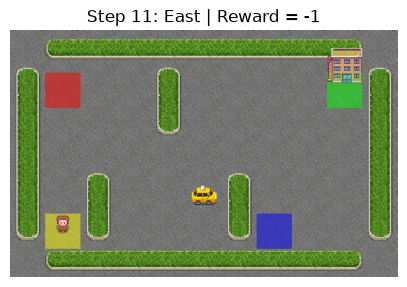

Step 12: State 349 → 349, Action = East, Reward = -1, Discount = 0.3138, Discounted reward = -0.3138


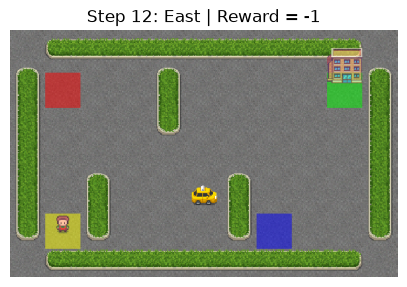

Step 13: State 349 → 349, Action = East, Reward = -1, Discount = 0.2824, Discounted reward = -0.2824


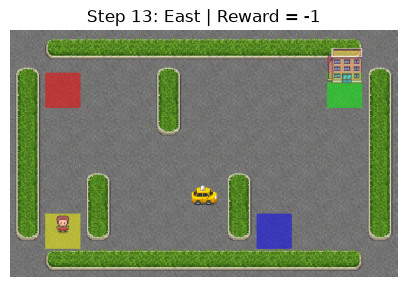

Step 14: State 349 → 249, Action = North, Reward = -1, Discount = 0.2542, Discounted reward = -0.2542


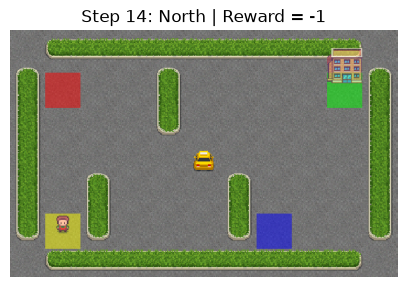

Step 15: State 249 → 229, Action = West, Reward = -1, Discount = 0.2288, Discounted reward = -0.2288


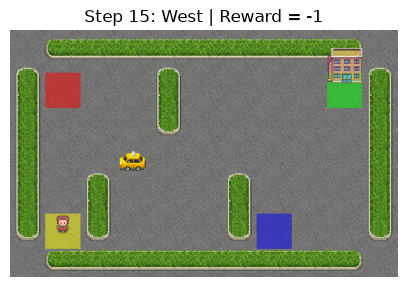

Step 16: State 229 → 229, Action = Pick up, Reward = -10, Discount = 0.2059, Discounted reward = -2.0589


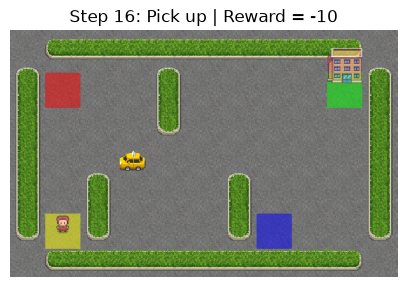

Step 17: State 229 → 209, Action = West, Reward = -1, Discount = 0.1853, Discounted reward = -0.1853


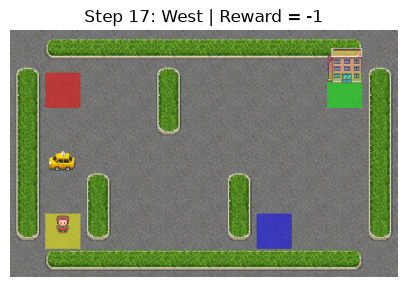

Step 18: State 209 → 209, Action = Drop off, Reward = -10, Discount = 0.1668, Discounted reward = -1.6677


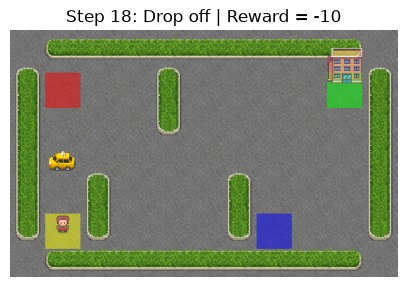

Step 19: State 209 → 309, Action = South, Reward = -1, Discount = 0.1501, Discounted reward = -0.1501


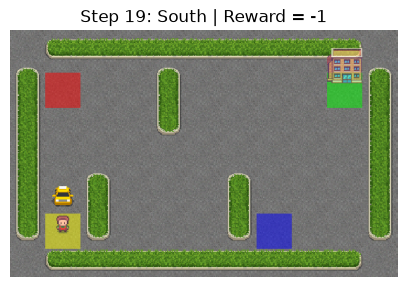

Step 20: State 309 → 209, Action = North, Reward = -1, Discount = 0.1351, Discounted reward = -0.1351


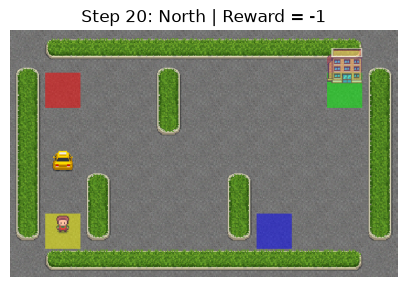


Total reward: -92
Discounted return: -43.22193549691615


In [23]:
import gymnasium as gym
import matplotlib.pyplot as plt

env = gym.make(
    "Taxi-v4",
    render_mode="rgb_array"
)

state, info = env.reset()

# Show the initial state
plt.figure(figsize=(5, 5))
plt.imshow(env.render())
plt.axis("off")
plt.title(f"Initial State: {state}")
plt.show()

gamma = 0.90
discounted_return = 0
total_reward = 0

action_names = {
    0: "South",
    1: "North",
    2: "East",
    3: "West",
    4: "Pick up",
    5: "Drop off"
}

for step in range(20):
    action = env.action_space.sample()

    next_state, reward, terminated, truncated, info = env.step(action)

    discount = gamma ** step
    discounted_reward = discount * reward

    total_reward += reward
    discounted_return += discounted_reward

    print(
        f"Step {step + 1}: "
        f"State {state} → {next_state}, "
        f"Action = {action_names[action]}, "
        f"Reward = {reward}, "
        f"Discount = {discount:.4f}, "
        f"Discounted reward = {discounted_reward:.4f}"
    )

    # Show Taxi after this action
    frame = env.render()

    plt.figure(figsize=(5, 5))
    plt.imshow(frame)
    plt.axis("off")
    plt.title(
        f"Step {step + 1}: "
        f"{action_names[action]} | "
        f"Reward = {reward}"
    )
    plt.show()

    state = next_state

    if terminated or truncated:
        print("Episode finished.")
        break

print("\nTotal reward:", total_reward)
print("Discounted return:", discounted_return)

env.close()

### 6. Value

A **value function** measures how good a state or action is based on the future rewards the agent is expected to receive.

There are two main types of value functions.

### 6.1. State-Value Function

The state-value function measures how good it is for the agent to be in a state while following a policy
, and defined as:

$$
V^\pi(s)
=
\mathbb{E}_\pi
\left[
G_t \mid S_t=s
\right]
$$



A state with a high value is expected to lead to better future rewards.

### 6.2. Action-Value Function

The action-value function measures how good it is to take a particular action in a particular state ,and defined as:

$$
Q^\pi(s,a)
=
\mathbb{E}_\pi
\left[
G_t \mid S_t=s, A_t=a
\right]
$$

### Difference Between $V$ and $Q$

| Function | Question |
|---|---|
| $V^\pi(s)$ | How good is this state? |
| $Q^\pi(s,a)$ | How good is this action in this state? |

For an optimal policy, the value of a state can be obtained from the best action value:

$$
V^*(s)=\max_a Q^*(s,a)
$$


In [96]:
import gymnasium as gym
import numpy as np

env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=False
)

state, info = env.reset(seed=42)

action_names = {
    0: "Left",
    1: "Down",
    2: "Right",
    3: "Up"
}

q_values = np.array([0.10, 0.30, 0.80, 0.05])

best_action = np.argmax(q_values)
state_value = np.max(q_values)

next_state, reward, terminated, truncated, info = env.step(best_action)

print("Current state:", state)
print("Q-values for this state:", q_values)
print("Best action:", best_action, "=", action_names[best_action])
print("State value V(s):", state_value)
print("Next state:", next_state)
print("Reward:", reward)

env.close()

Current state: 0
Q-values for this state: [0.1  0.3  0.8  0.05]
Best action: 2 = Right
State value V(s): 0.8
Next state: 1
Reward: 0


Contributed by : Lama Ayash